# 📥 Data Loading
Load the raw text data into the notebook.

In [2]:
file=open("Royal_data.txt",'r')
royal_data=file.read()
file.close()
print(royal_data)

In the ancient kingdom of Elyria, four figures shaped the destiny of the land: the king, the queen, the man, and the woman. Though they lived in the same world, their roles, relationships, and meanings were deeply connected in ways not immediately visible.

The king ruled from the grand palace, a symbol of authority and strength. Beside him sat the queen, equally wise, guiding decisions with calm intelligence. While the people often saw the king as power, those who observed closely knew that the queen balanced that power with insight and compassion.

Beyond the palace walls lived the man and the woman, ordinary citizens of Elyria. The man worked in the fields, strong and determined, while the woman managed the home and contributed to the village with equal resilience and care. Though their titles were simple compared to the king and queen, their roles reflected a similar partnership.

One day, a young scholar arrived in Elyria. He was curious about the structure of the kingdom. Watchin

# 🧹 Text Preprocessing
Clean the text by removing special characters, numbers, and formatting.

In [4]:
import re
clean_text = re.sub(r'[^a-zA-Z\s\.]', '', royal_data)
clean_text = clean_text.replace("\n", ".")
clean_text = re.sub(r'\.{2,}', '.', clean_text)
sentences = clean_text.split('.')
print(sentences)

['In the ancient kingdom of Elyria four figures shaped the destiny of the land the king the queen the man and the woman', ' Though they lived in the same world their roles relationships and meanings were deeply connected in ways not immediately visible', 'The king ruled from the grand palace a symbol of authority and strength', ' Beside him sat the queen equally wise guiding decisions with calm intelligence', ' While the people often saw the king as power those who observed closely knew that the queen balanced that power with insight and compassion', 'Beyond the palace walls lived the man and the woman ordinary citizens of Elyria', ' The man worked in the fields strong and determined while the woman managed the home and contributed to the village with equal resilience and care', ' Though their titles were simple compared to the king and queen their roles reflected a similar partnership', 'One day a young scholar arrived in Elyria', ' He was curious about the structure of the kingdom', 

# 🚫 Stopword 

In [3]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/santhosh/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 🚫 Stopword Removal
Remove common words that do not contribute to meaning.

In [5]:
stop_words = set(stopwords.words('english'))
print(len(stop_words))

198


# ✂️ Sentence Tokenization
Split the cleaned text into sentences.

In [6]:
filtered_data = []
for sent in sentences:
    temp = []
    for word in sent.split():
        if word not in stop_words:
            temp.append(word)
    filtered_data.append(temp)

print(filtered_data)

[['In', 'ancient', 'kingdom', 'Elyria', 'four', 'figures', 'shaped', 'destiny', 'land', 'king', 'queen', 'man', 'woman'], ['Though', 'lived', 'world', 'roles', 'relationships', 'meanings', 'deeply', 'connected', 'ways', 'immediately', 'visible'], ['The', 'king', 'ruled', 'grand', 'palace', 'symbol', 'authority', 'strength'], ['Beside', 'sat', 'queen', 'equally', 'wise', 'guiding', 'decisions', 'calm', 'intelligence'], ['While', 'people', 'often', 'saw', 'king', 'power', 'observed', 'closely', 'knew', 'queen', 'balanced', 'power', 'insight', 'compassion'], ['Beyond', 'palace', 'walls', 'lived', 'man', 'woman', 'ordinary', 'citizens', 'Elyria'], ['The', 'man', 'worked', 'fields', 'strong', 'determined', 'woman', 'managed', 'home', 'contributed', 'village', 'equal', 'resilience', 'care'], ['Though', 'titles', 'simple', 'compared', 'king', 'queen', 'roles', 'reflected', 'similar', 'partnership'], ['One', 'day', 'young', 'scholar', 'arrived', 'Elyria'], ['He', 'curious', 'structure', 'kingd

# 🔗 Context Pair Generation
Generate word pairs using a context window.

In [7]:
window_size = 2
bigrams = []

for words_list in filtered_data:
    for i in range(len(words_list)):
        for j in range(max(0, i - window_size), min(len(words_list), i + window_size + 1)):
            if i != j:
                bigrams.append([words_list[i], words_list[j]])

In [8]:
all_words = []
for bi in bigrams:
    all_words.extend(bi)

all_words = list(set(all_words))
all_words.sort()

print(all_words)
print("Total number of unique words are:", len(all_words))

['And', 'As', 'Beside', 'Beyond', 'Each', 'Elyria', 'Elyriaunderstanding', 'Eventually', 'He', 'If', 'In', 'It', 'One', 'The', 'Their', 'Though', 'To', 'Watching', 'While', 'Words', 'alongside', 'ancient', 'arrived', 'authority', 'balance', 'balanced', 'calm', 'care', 'caregiver', 'carrying', 'citizens', 'closely', 'comes', 'compared', 'compassion', 'connected', 'connection', 'context', 'contributed', 'could', 'create', 'curious', 'day', 'days', 'decisions', 'deeply', 'defined', 'definition', 'definitions', 'described', 'destiny', 'determined', 'differ', 'differed', 'elevated', 'equal', 'equally', 'equivalent', 'example', 'explained', 'fascinated', 'fields', 'figures', 'formed', 'four', 'gains', 'give', 'grand', 'guiding', 'home', 'idea', 'imagined', 'immediately', 'insight', 'intelligence', 'interaction', 'isolated', 'kind', 'king', 'kingdom', 'knew', 'land', 'languagejust', 'leadership', 'left', 'like', 'listened', 'lived', 'living', 'man', 'managed', 'may', 'meaning', 'meanings', 'm

# 🔤 Word Tokenization
Convert sentences into lists of words.

In [9]:
words_dict = {}

counter = 0
for word in all_words:
    words_dict[word] = counter
    counter += 1

print(words_dict)

{'And': 0, 'As': 1, 'Beside': 2, 'Beyond': 3, 'Each': 4, 'Elyria': 5, 'Elyriaunderstanding': 6, 'Eventually': 7, 'He': 8, 'If': 9, 'In': 10, 'It': 11, 'One': 12, 'The': 13, 'Their': 14, 'Though': 15, 'To': 16, 'Watching': 17, 'While': 18, 'Words': 19, 'alongside': 20, 'ancient': 21, 'arrived': 22, 'authority': 23, 'balance': 24, 'balanced': 25, 'calm': 26, 'care': 27, 'caregiver': 28, 'carrying': 29, 'citizens': 30, 'closely': 31, 'comes': 32, 'compared': 33, 'compassion': 34, 'connected': 35, 'connection': 36, 'context': 37, 'contributed': 38, 'could': 39, 'create': 40, 'curious': 41, 'day': 42, 'days': 43, 'decisions': 44, 'deeply': 45, 'defined': 46, 'definition': 47, 'definitions': 48, 'described': 49, 'destiny': 50, 'determined': 51, 'differ': 52, 'differed': 53, 'elevated': 54, 'equal': 55, 'equally': 56, 'equivalent': 57, 'example': 58, 'explained': 59, 'fascinated': 60, 'fields': 61, 'figures': 62, 'formed': 63, 'four': 64, 'gains': 65, 'give': 66, 'grand': 67, 'guiding': 68, '

# 🧠 Training Data Preparation
Convert words into one-hot encoded vectors.

In [10]:
import numpy as np

onehot_data = np.zeros((len(all_words), len(all_words)))

for i in range(len(all_words)):
    onehot_data[i][i] = 1

onehot_dict = {}
counter = 0
for word in all_words:
    onehot_dict[word] = onehot_data[counter]
    counter += 1

for word in onehot_dict:
    print(word, ":", onehot_dict[word])

And : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
As : [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Beside : [0. 

In [11]:
X = []
Y = []

for bi in bigrams:
    X.append(onehot_dict[bi[0]])
    Y.append(onehot_dict[bi[1]])

X = np.array(X)
Y = np.array(Y)

# 🏗️ Model Architecture
Define the neural network for word embedding.


In [12]:
from keras.models import Sequential
from keras.layers import Dense

embed_size = 3

model = Sequential([
    Dense(embed_size, activation='linear'),
    Dense(Y.shape[1], activation = 'softmax')
])

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam')

2026-04-25 10:26:31.835778: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 10:26:32.083382: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-25 10:26:33.427906: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777092996.301433   18952 gpu_device.cc:2020] Created device /job:localhost/rep

# 🔄 Model Training
Train the embedding model on the dataset.

In [13]:
model.fit(X, Y, epochs = 1000, batch_size = 256, verbose = False)

2026-04-25 10:26:37.077194: I external/local_xla/xla/service/service.cc:163] XLA service 0x7470dc0034f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-25 10:26:37.077240: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2050, Compute Capability 8.6
2026-04-25 10:26:37.103322: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-25 10:26:37.218828: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
I0000 00:00:1777092998.249053   19265 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-25 10:26:38.765720: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_82', 4 

# 📦 Extracting Word Embeddings
Retrieve learned vector representations for words.

In [14]:
weights = model.get_weights()[0]

word_embeddings = {}
for word in all_words:
    word_embeddings[word] = weights[words_dict[word]]
print(word_embeddings)

{'And': array([2.4881384 , 0.23757516, 0.32017422], dtype=float32), 'As': array([ 1.4398985 , -1.6693702 ,  0.47898442], dtype=float32), 'Beside': array([-0.0243605 ,  0.42826846,  1.7764616 ], dtype=float32), 'Beyond': array([-2.3761566,  1.7541451, -1.4966466], dtype=float32), 'Each': array([-0.32539016, -1.9489654 , -0.97368526], dtype=float32), 'Elyria': array([ 1.3798089 , -1.0343688 ,  0.22745273], dtype=float32), 'Elyriaunderstanding': array([-0.33064187,  1.4101796 , -1.3799882 ], dtype=float32), 'Eventually': array([ 0.6758803 , -2.2705429 ,  0.47233114], dtype=float32), 'He': array([-0.85154825,  1.1949236 , -0.15479544], dtype=float32), 'If': array([-0.82826865,  1.0583043 ,  1.4223003 ], dtype=float32), 'In': array([ 0.9554961 ,  1.1228025 , -0.40133223], dtype=float32), 'It': array([-0.29625747, -1.7997259 , -1.6161247 ], dtype=float32), 'One': array([ 1.9257658, -1.7716446,  2.3614588], dtype=float32), 'The': array([-0.8320299,  0.5181149,  1.2842323], dtype=float32), 'Th

# 📊 2D Visualization of Word Embeddings
Plot word vectors in 2D space.

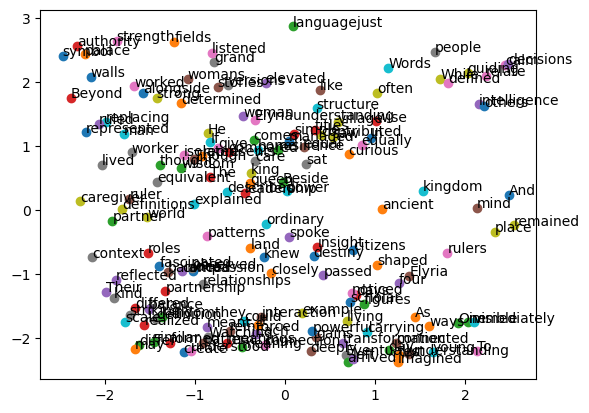

In [15]:
import matplotlib.pyplot as plt

# plt.figure(figsize = (10, 10))
for word in list(words_dict.keys()):
    coord = word_embeddings.get(word)
    plt.scatter(coord[0], coord[1])
    plt.annotate(word, (coord[0], coord[1]))

plt.savefig('img.jpg')

# 🌐 3D Visualization of Word Embeddings
Plot word vectors in 3D space with fixed axis range.

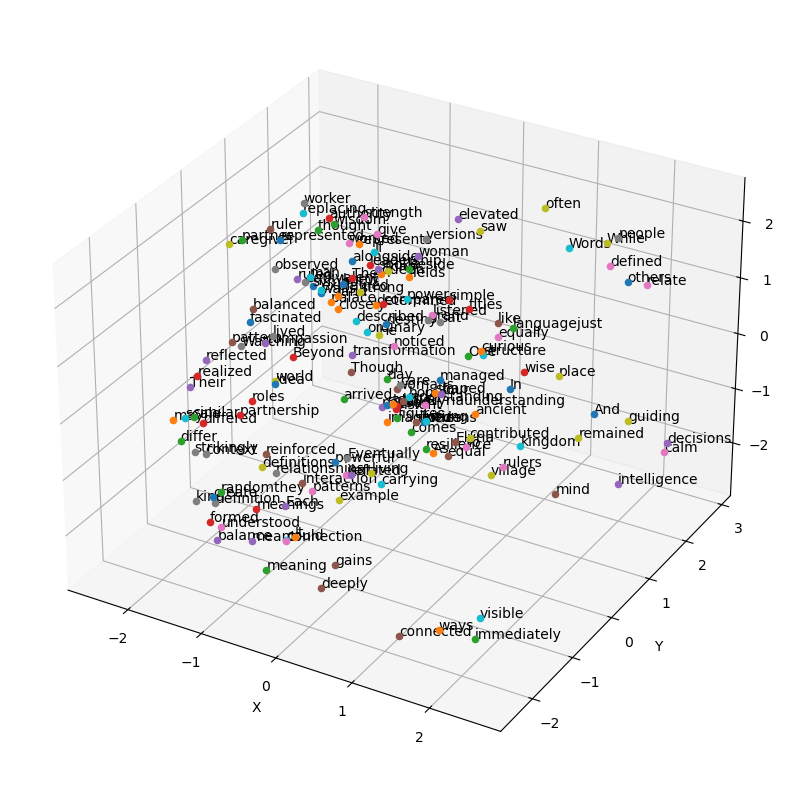

In [16]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # important
# %matplotlib notebook
# Create 3D figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each word
for word in list(words_dict.keys()):
    coord = word_embeddings.get(word)
    
    x, y, z = coord[0], coord[1], coord[2]
    
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

# Labels (optional but useful)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.savefig('img_3d.jpg')
plt.show()

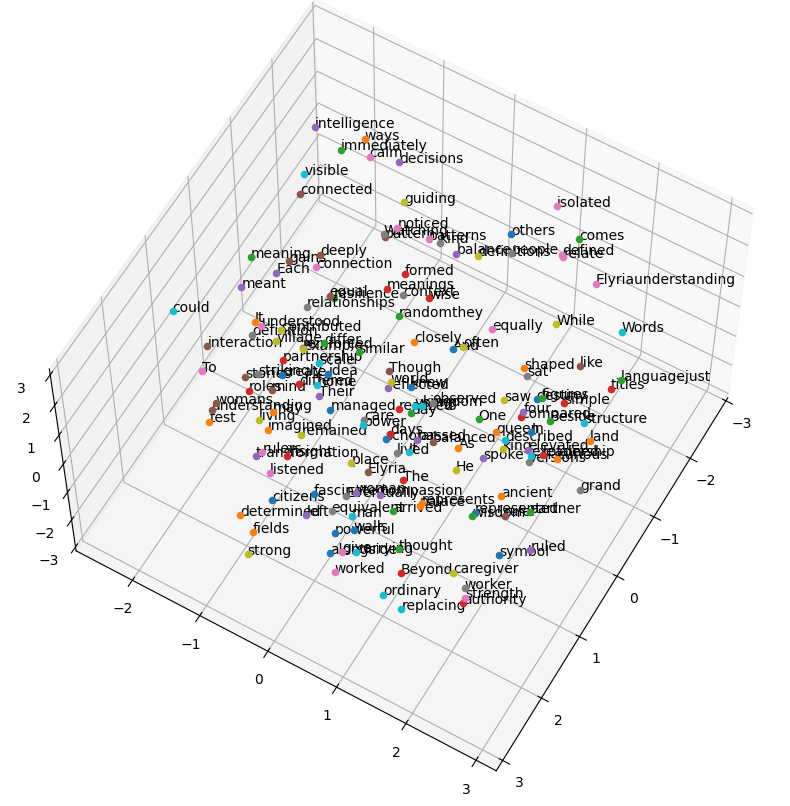

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for word in words_dict.keys():
    x, y, z = word_embeddings[word]
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

# Rotate view
ax.view_init(elev=60, azim=30)   # change elev for up/down

plt.show()

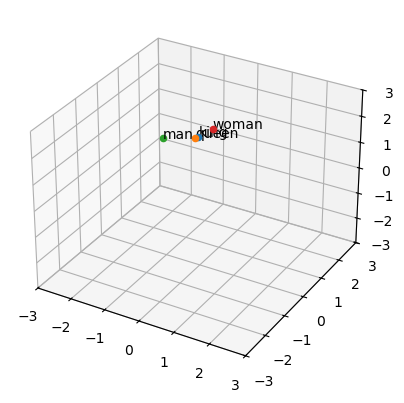

In [19]:
words = ["king", "queen", "man", "woman"]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for word in words:
    vec = word_embeddings.get(word)
    ax.scatter(vec[0], vec[1], vec[2])
    ax.text(vec[0], vec[1], vec[2], word)

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(-3, 3)

plt.show()

# 🤴 King = (👑 Queen - 👩 Woman) + 👨 Man

#

In [ ]:
man=word_embeddings.get("man")
woman=word_embeddings.get("woman")
queen=word_embeddings.get("queen")
king=word_embeddings.get("king")


predicted_king=(queen-woman)+man

print(predicted_king)
print(king)

[-0.24887466  1.3178796  -1.7933027 ]
[-0.1416055  1.5168856 -1.0811272]


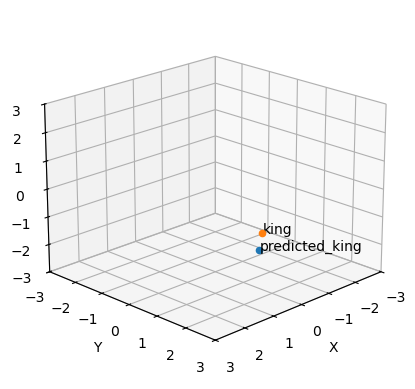

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(predicted_king[0], predicted_king[1], predicted_king[2])
ax.text(predicted_king[0], predicted_king[1], predicted_king[2], "predicted_king")
ax.scatter(king[0], king[1], king[2])
ax.text(king[0], king[1], king[2], "king")

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_zlim(-3, 3)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(elev=20, azim=45)

plt.show()